In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.neighbors import KNeighborsRegressor

In [2]:
df = pd.read_csv('data/data_cleaned.csv')
df

,MWG,NWG,KWG,MDIMC,NDIMC,MDIMA,NDIMB,KWI,VWM,VWN,STRM,STRN,SA,SB,Time
0,-1,-1,0,-1,-1,-1,-1,0,-1,-1,0,0,0,0,116.3700
1,-1,-1,0,-1,-1,-1,-1,0,-1,-1,0,0,0,1,78.7050
2,-1,-1,0,-1,-1,-1,-1,0,-1,-1,0,0,1,0,80.5650
3,-1,-1,0,-1,-1,-1,-1,0,-1,-1,0,0,1,1,86.6375
4,-1,-1,0,-1,-1,-1,-1,0,-1,-1,0,1,0,0,118.6625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241595,2,2,1,1,1,1,1,1,1,1,1,0,1,1,17.8175
241596,2,2,1,1,1,1,1,1,1,1,1,1,0,0,36.0350
241597,2,2,1,1,1,1,1,1,1,1,1,1,0,1,35.1600
241598,2,2,1,1,1,1,1,1,1,1,1,1,1,0,28.4525


In [3]:
correlations = df.corr()['Time'].drop('Time')
correlations

MWG      0.327515
NWG      0.295645
KWG      0.011230
MDIMC   -0.238080
NDIMC   -0.231960
MDIMA   -0.011015
NDIMB   -0.012549
KWI      0.032571
VWM      0.155638
VWN      0.137250
STRM    -0.012586
STRN    -0.000108
SA       0.051975
SB       0.063963
Name: Time, dtype: float64

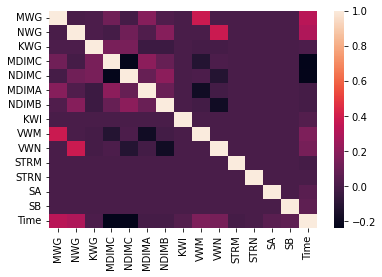

In [4]:
sns.heatmap(df.corr())
plt.show()

In [5]:
def get_features(correlation_threshold):
    abs_corrs = correlations.abs()
    high_correlations = abs_corrs[abs_corrs > correlation_threshold].index.values.tolist()
    return high_correlations

In [6]:
features = get_features(0.05) 
print(features) 
X = df[features] 
y = df['Time']

['MWG', 'NWG', 'MDIMC', 'NDIMC', 'VWM', 'VWN', 'SA', 'SB']


In [7]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=99)

In [33]:
# Fit linear regression to training data
lr = LinearRegression()
lr.fit(X_train,y_train)

# Predict
train_pred=lr.predict(X_train)
lr_pred = lr.predict(X_test)
lr_pred = np.clip(lr_pred, 0, max(lr_pred))

print('Mean Absolute Error:', mean_absolute_error(y_test, lr_pred))
print('Mean Squared Error:', mean_squared_error(y_test, lr_pred))

Mean Absolute Error: 155.74972854449882
Mean Squared Error: 73757.87559369687


In [9]:
# displaying coefficients of each feature
coeffecients = pd.DataFrame(lr.coef_,features)
coeffecients.columns = ['Coeffecient'] 
coeffecients

,Coeffecient
MWG,144.094118
NWG,132.490063
MDIMC,-189.169975
NDIMC,-184.481773
VWM,-9.425797
VWN,-11.650127
SA,38.691486
SB,47.979997


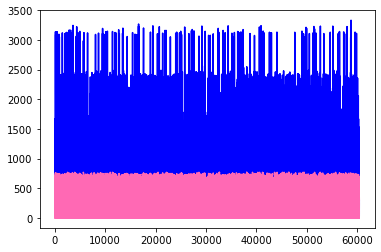

In [34]:
y_test.reset_index(inplace=True, drop=True)
plt.plot(y_test, 'b')
plt.plot(lr_pred, ls = '--', color='hotpink')
plt.legend
plt.show()

In [11]:
alphas = 10**np.linspace(10,-2,100)*0.5
ridgecv = RidgeCV(alphas = alphas, scoring = 'neg_mean_squared_error')
ridgecv.fit(X_train, y_train)
ridgecv.alpha_

5.361336110051605

In [12]:
ridge = Ridge(alpha = ridgecv.alpha_, normalize = True)
ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

print('Mean Absolute Error:', mean_absolute_error(y_test, ridge_pred))
print('Mean Squared Error:', mean_squared_error(y_test, ridge_pred))

Mean Absolute Error: 198.54255961755507
Mean Squared Error: 121557.2268771926


C:\Users\cavlo\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Ridge())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * n_samples. 
  warnings.warn(


In [13]:
# displaying coefficients of each feature
coeffecients = pd.DataFrame(ridge.coef_,features)
coeffecients.columns = ['Coeffecient'] 
coeffecients

,Coeffecient
MWG,19.524725
NWG,17.668871
MDIMC,-20.592329
NDIMC,-20.027303
VWM,7.984781
VWN,7.028867
SA,6.088676
SB,7.560564


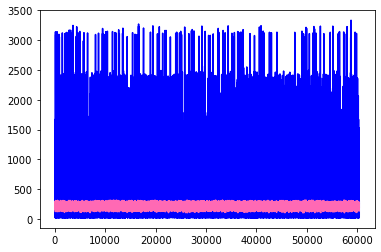

In [14]:
plt.plot(y_test, 'b')
plt.plot(ridge_pred, ls = '--', color='hotpink')
plt.legend
plt.show()

In [15]:
lassocv = LassoCV(alphas=None, cv=10, max_iter=100000, normalize = True)
lassocv.fit(X_train, y_train)
lassocv.alpha_

C:\Users\cavlo\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Lasso())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * np.sqrt(n_samples). 
  warnings.warn(


0.0002830614073766231

In [31]:
lasso = Lasso(alpha = lassocv.alpha_, normalize = True)
lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)
lasso_pred = np.clip(lasso_pred, 0, max(lasso_pred))

print('Mean Absolute Error:', mean_absolute_error(y_test, lasso_pred))
print('Mean Squared Error:', mean_squared_error(y_test, lasso_pred))

Mean Absolute Error: 155.73346900182415
Mean Squared Error: 73793.95809844036


C:\Users\cavlo\anaconda3\lib\site-packages\sklearn\linear_model\_base.py:141: FutureWarning: 'normalize' was deprecated in version 1.0 and will be removed in 1.2.
If you wish to scale the data, use Pipeline with a StandardScaler in a preprocessing stage. To reproduce the previous behavior:

from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(with_mean=False), Lasso())

If you wish to pass a sample_weight parameter, you need to pass it as a fit parameter to each step of the pipeline as follows:

kwargs = {s[0] + '__sample_weight': sample_weight for s in model.steps}
model.fit(X, y, **kwargs)

Set parameter alpha to: original_alpha * np.sqrt(n_samples). 
  warnings.warn(


In [17]:
# displaying coefficients of each feature
coeffecients = pd.DataFrame(lasso.coef_,features)
coeffecients.columns = ['Coeffecient'] 
coeffecients

,Coeffecient
MWG,143.850728
NWG,132.248152
MDIMC,-188.857990
NDIMC,-184.170611
VWM,-9.183928
VWN,-11.408156
SA,38.449606
SB,47.739616


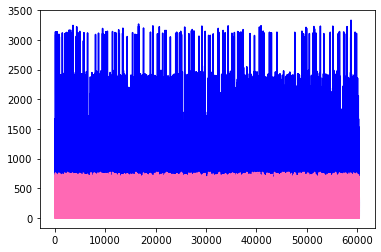

In [32]:
plt.plot(y_test, 'b')
plt.plot(lasso_pred, ls = '--', color='hotpink')
plt.legend
plt.show()

In [19]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

Mean Absolute Error: 47.71941659768211
Mean Squared Error: 18441.745464745934


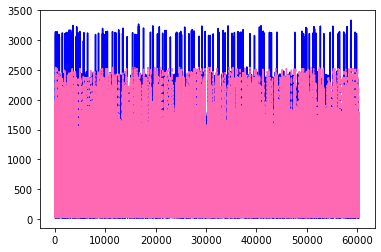

In [20]:
plt.plot(y_test, 'b')
plt.plot(y_pred, ls = '--', color='hotpink')
plt.legend
plt.show()

In [21]:
err = []

# Calculating error for K values between 1 and 40
for i in range(1, 40):
    clf = KNeighborsRegressor(n_neighbors=i)
    clf.fit(X_train, y_train)
    pred_i = clf.predict(X_test)
    err.append(mean_absolute_error(y_test, pred_i))
    print(i)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39


Text(0, 0.5, 'Mean Error')

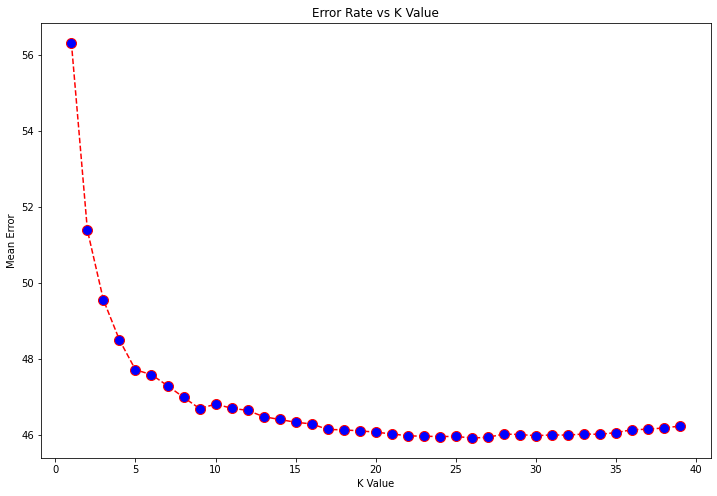

In [22]:
plt.figure(figsize=(12, 8))
plt.plot(range(1, 40), err, color='red', linestyle='dashed', marker='o',
         markerfacecolor='blue', markersize=10)
plt.title('Error Rate vs K Value')
plt.xlabel('K Value')
plt.ylabel('Mean Error')

In [24]:
err.index(min(err)) + 1

26

In [25]:
knn = KNeighborsRegressor(n_neighbors=26)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))

Mean Absolute Error: 45.922684029546616
Mean Squared Error: 16388.233359428294


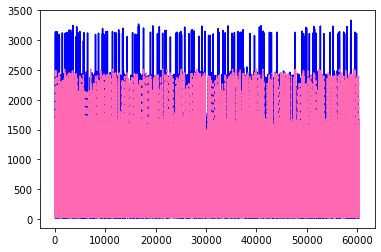

In [28]:
plt.plot(y_test, 'b')
plt.plot(y_pred, ls = '--', color='hotpink')
plt.legend
plt.show()